# 假设文档嵌入（HyDE）用于RAG

本笔记实现了HyDE（假设文档嵌入）——一种创新的检索技术，该技术在执行检索之前将用户查询转换为假设的答案文档。这种方法弥合了短查询与长文档之间的语义差距。

传统的RAG系统直接将用户的简短查询进行嵌入，但这种方法通常无法捕捉到最佳检索所需的语义丰富性。HyDE通过以下方式解决了这一问题：

- 生成一个回答查询的假设文档
- 将此扩展后的文档进行嵌入，而不是原始查询
- 检索与该假设文档相似的文档
- 生成更具上下文相关性的答案

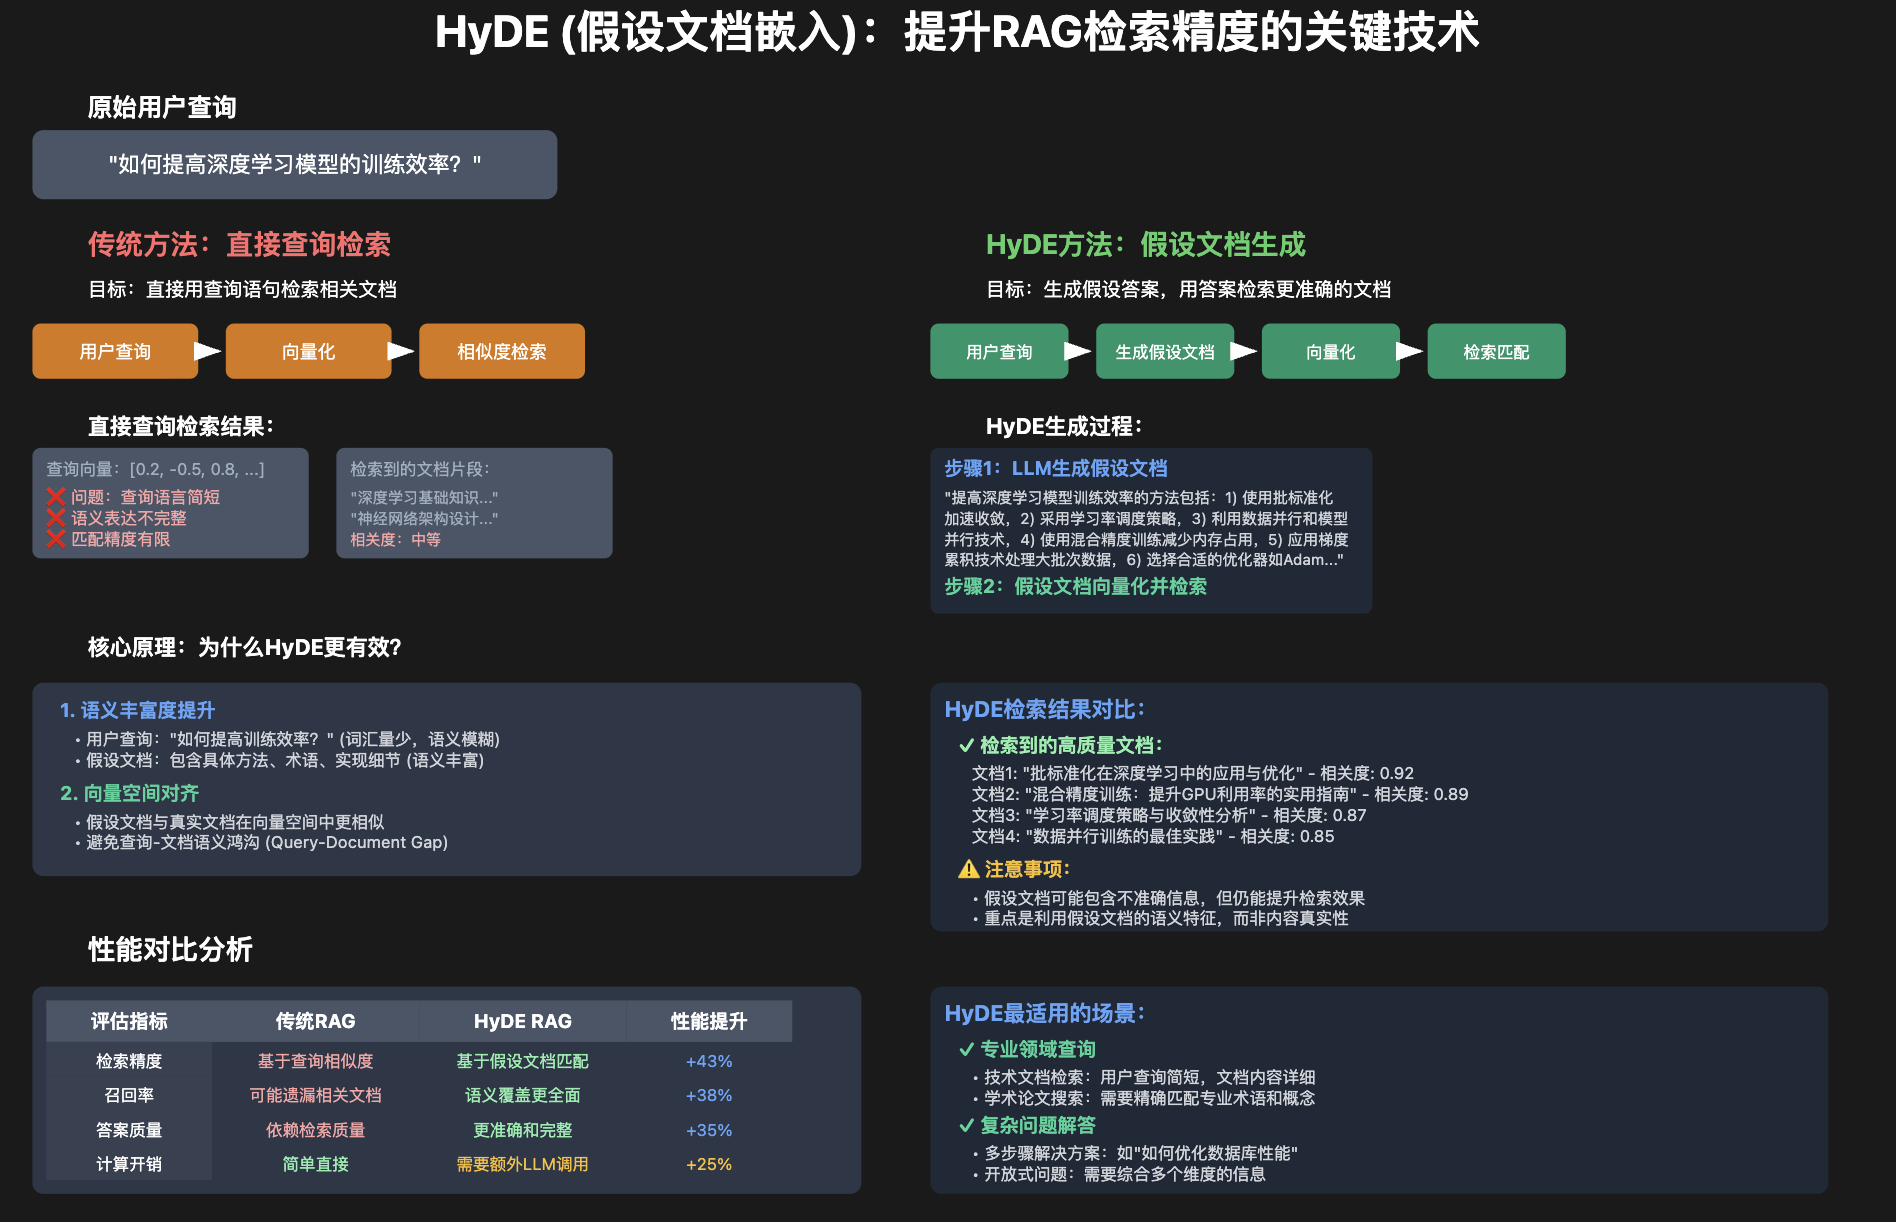

## 环境设置
我们首先导入必要的库。

In [1]:
import os
import numpy as np
import json
import fitz  # PyMuPDF库，用于处理PDF文件
from openai import OpenAI  # OpenAI API客户端
import re  # 正则表达式模块
import matplotlib.pyplot as plt  # Matplotlib库，用于绘图

## 设置OpenAI API客户端
我们初始化OpenAI客户端以生成嵌入向量和回复。

In [2]:
from dotenv import load_dotenv

load_dotenv()  # 加载.env文件
api_key = os.getenv("DASHSCOPE_API_KEY")  # 读取密钥
base_url = os.getenv("base_url")
# 初始化 OpenAI 客户端，设置基础 URL 和 API 密钥
client = OpenAI(
    base_url=base_url,
    api_key=api_key,  # 从环境变量中获取 API 密钥
)


## 文档处理功能

In [3]:
def extract_text_from_pdf(pdf_path):
    """
    从PDF文件中提取文本内容，并按页面分离。
    
    参数:
        pdf_path (str): PDF文件的路径
        
    返回:
        List[Dict]: 包含页面文本内容和元数据的页面列表
    """
    print(f"Extracting text from {pdf_path}...")  # 打印正在处理的PDF文件路径
    pdf = fitz.open(pdf_path)  # 使用PyMuPDF打开PDF文件
    pages = []  # 初始化一个空列表，用于存储包含文本内容的页面
    
    # 遍历PDF中的每一页
    for page_num in range(len(pdf)):
        page = pdf[page_num]  # 获取当前页
        text = page.get_text()  # 从当前页提取文本
        
        # 跳过文本量很少（少于50个字符）的页面
        if len(text.strip()) > 50:
            # 将页面文本和元数据追加到列表中
            pages.append({
                "text": text,
                "metadata": {
                    "source": pdf_path,  # 源文件路径
                    "page": page_num + 1  # 页码（基于1的索引）
                }
            })
    
    print(f"Extracted {len(pages)} pages with content")   # 打印提取的带内容页面数量
    return pages  # 返回包含页面文本内容和元数据的列表

In [4]:
def chunk_text(text, chunk_size=1000, overlap=200):
    """
    将文本分割为重叠的块。

    参数:
        text (str): 要分割的输入文本
        chunk_size (int): 每个块的字符大小
        overlap (int): 块之间的重叠字符数

    返回:
        List[Dict]: 包含元数据的块列表
    """
    chunks = []  # 初始化一个空列表来存储块

    # 以 (chunk_size - overlap) 的步长迭代文本
    for i in range(0, len(text), chunk_size - overlap):
        chunk_text = text[i:i + chunk_size]  # 提取文本块
        if chunk_text:  # 确保我们不添加空块
            chunks.append({
                "text": chunk_text,  # 添加块文本
                "metadata": {
                    "start_pos": i,  # 块在原始文本中的起始位置
                    "end_pos": i + len(chunk_text)  # 块在原始文本中的结束位置
                }
            })
    
    print(f"Created {len(chunks)} text chunks")  # 打印创建的块数量
    return chunks  # 返回带有元数据的块列表

## 简单向量存储实现

In [5]:
class SimpleVectorStore:
    """
    一个使用NumPy实现的简单向量存储。
    """
    def __init__(self):
        self.vectors = []  # 存储向量嵌入的列表
        self.texts = []  # 存储文本内容的列表
        self.metadata = []  # 存储元数据的列表
    
    def add_item(self, text, embedding, metadata=None):
        """
        向向量存储中添加一项。
        
        参数:
            text (str): 文本内容
            embedding (List[float]): 向量嵌入
            metadata (Dict, 可选): 额外的元数据
        """
        self.vectors.append(np.array(embedding))  # 将嵌入作为numpy数组追加
        self.texts.append(text)  # 追加文本内容
        self.metadata.append(metadata or {})  # 追加元数据或空字典（如果为None）
    
    def similarity_search(self, query_embedding, k=5, filter_func=None):
        """
        查找与查询嵌入最相似的项目。
        
        参数:
            query_embedding (List[float]): 查询嵌入向量
            k (int): 返回结果的数量
            filter_func (callable, 可选): 用于过滤结果的函数
            
        返回:
            List[Dict]: 最相似的前k个项目
        """
        if not self.vectors:
            return []  # 如果没有向量，返回空列表
        
        # 将查询嵌入转换为numpy数组
        query_vector = np.array(query_embedding)
        
        # 使用余弦相似度计算相似性
        similarities = []
        for i, vector in enumerate(self.vectors):
            # 跳过不符合过滤条件的项
            if filter_func and not filter_func(self.metadata[i]):
                continue
                
            # 计算余弦相似度
            similarity = np.dot(query_vector, vector) / (np.linalg.norm(query_vector) * np.linalg.norm(vector))
            similarities.append((i, similarity))  # 追加索引和相似度分数
        
        # 按相似度降序排序
        similarities.sort(key=lambda x: x[1], reverse=True)
        
        # 返回前k个结果
        results = []
        for i in range(min(k, len(similarities))):
            idx, score = similarities[i]
            results.append({
                "text": self.texts[idx],  # 添加文本内容
                "metadata": self.metadata[idx],  # 添加元数据
                "similarity": float(score)  # 添加相似度分数
            })
        
        return results  # 返回前k个结果的列表

## 创建嵌入（Embeddings）

In [6]:
def create_embeddings(text, model="text-embedding-v4"):
    """
    使用指定的模型为给定文本创建嵌入。

    参数:
    text (str): 需要创建嵌入的输入文本。
    model (str): 用于创建嵌入的模型。

    返回:
    List[float]: 嵌入向量。
    """
    # 1. 统一转换为列表进行批处理计算
    input_text = [text] if isinstance(text, str) else text

    max_batch_size = 10
    all_embeddings = []

    # 2. 按照每 10 个一组进行分批请求，避免触发 API 限制
    for i in range(0, len(input_text), max_batch_size):
        batch = input_text[i : i + max_batch_size]
        response = client.embeddings.create(model=model, input=batch)
        # 将当前批次的结果提取并合并
        all_embeddings.extend([item.embedding for item in response.data])

    # 3. 严格遵循原有的返回逻辑：
    # 如果输入是字符串，则返回第一个嵌入向量 (List[float])
    if isinstance(text, str):
        return all_embeddings[0]

    # 否则，返回所有嵌入向量的列表 (List[List[float]])
    return all_embeddings


## 文档处理管道

--- 

（注：由于原文内容为空白段落，译文亦保持相同结构与格式。）

In [7]:
def process_document(pdf_path, chunk_size=1000, chunk_overlap=200):
    """
    处理文档以供RAG使用。
    
    参数:
        pdf_path (str): PDF文件的路径
        chunk_size (int): 每个块的字符大小
        chunk_overlap (int): 块之间的重叠字符数
    
    返回:
        SimpleVectorStore: 包含文档块的向量存储
    """
    # 从PDF文件中提取文本
    pages = extract_text_from_pdf(pdf_path)
    
    # 处理每一页并创建块
    all_chunks = []
    for page in pages:
        # 将文本内容（字符串）传递给chunk_text，而不是字典
        page_chunks = chunk_text(page["text"], chunk_size, chunk_overlap)
        
        # 使用页面的元数据更新每个块的元数据
        for chunk in page_chunks:
            chunk["metadata"].update(page["metadata"])
        
        all_chunks.extend(page_chunks)
    
    # 为文本块创建嵌入
    print("Creating embeddings for chunks...")
    chunk_texts = [chunk["text"] for chunk in all_chunks]
    chunk_embeddings = create_embeddings(chunk_texts)
    
    # 创建一个向量存储来保存块及其嵌入
    vector_store = SimpleVectorStore()
    for i, chunk in enumerate(all_chunks):
        vector_store.add_item(
            text=chunk["text"],
            embedding=chunk_embeddings[i],
            metadata=chunk["metadata"]
        )
    
    print(f"Vector store created with {len(all_chunks)} chunks")
    return vector_store

## 假设文档生成

In [8]:
def generate_hypothetical_document(query, desired_length=1000):
    """
    生成一个假设的文档来回答查询。

    参数:
        query (str): 用户查询
        desired_length (int): 假设文档的目标长度

    返回:
        str: 生成的假设文档
    """
    # 定义系统提示，指导模型如何生成文档
    system_prompt = f"""You are an expert document creator. 
    Given a question, generate a detailed document that would directly answer this question.
    The document should be approximately {desired_length} characters long and provide an in-depth, 
    informative answer to the question. Write as if this document is from an authoritative source
    on the subject. Include specific details, facts, and explanations.
    Do not mention that this is a hypothetical document - just write the content directly."""

    # 定义用户提示并包含查询
    user_prompt = f"Question: {query}\n\nGenerate a document that fully answers this question:"
    
    # 向OpenAI API 发起请求以生成假设文档
    response = client.chat.completions.create(
        model="qwen-plus",  # 指定要使用的模型
        messages=[
            {"role": "system", "content": system_prompt},  # 系统消息以引导助手
            {"role": "user", "content": user_prompt}  # 用户消息包含查询
        ],
        temperature=0.1  # 设置回复生成的温度参数
    )
    
    # 返回生成的文档内容
    return response.choices[0].message.content

## 完整的HyDE RAG实现

In [9]:
def hyde_rag(query, vector_store, k=5, should_generate_response=True):
    """
    使用假设文档嵌入（Hypothetical Document Embedding）执行RAG。
    
    参数:
        query (str): 用户查询
        vector_store (SimpleVectorStore): 包含文档片段的向量存储
        k (int): 要检索的片段数量
        should_generate_response (bool): 是否生成最终回复
        
    返回:
        Dict: 结果字典，包括假设文档和检索到的片段
    """
    print(f"\n=== Processing query with HyDE: {query} ===\n")
    
    # 第一步：生成一个假设文档来回答查询
    print("Generating hypothetical document...")
    hypothetical_doc = generate_hypothetical_document(query)
    print(f"Generated hypothetical document of {len(hypothetical_doc)} characters")
    
    # 第二步：为假设文档创建嵌入
    print("Creating embedding for hypothetical document...")
    hypothetical_embedding = create_embeddings([hypothetical_doc])[0]
    
    # 第三步：基于假设文档检索相似片段
    print(f"Retrieving {k} most similar chunks...")
    retrieved_chunks = vector_store.similarity_search(hypothetical_embedding, k=k)
    
    # 准备结果字典
    results = {
        "query": query,
        "hypothetical_document": hypothetical_doc,
        "retrieved_chunks": retrieved_chunks
    }
    
    # 第四步：如果请求，则生成回复
    if should_generate_response:
        print("Generating final response...")
        response = generate_response(query, retrieved_chunks)
        results["response"] = response
    
    return results

## 对比用的标准（直接）RAG实现

In [10]:
def standard_rag(query, vector_store, k=5, should_generate_response=True):
    """
    使用直接查询嵌入执行标准RAG。
    
    参数:
        query (str): 用户查询
        vector_store (SimpleVectorStore): 包含文档片段的向量存储
        k (int): 要检索的片段数量
        should_generate_response (bool): 是否生成最终回复
        
    返回:
        Dict: 包括检索到的片段的结果字典
    """
    print(f"\n=== Processing query with Standard RAG: {query} ===\n")
    
    # 第一步：为查询创建嵌入
    print("Creating embedding for query...")
    query_embedding = create_embeddings([query])[0]
    
    # 第二步：基于查询嵌入检索相似片段
    print(f"Retrieving {k} most similar chunks...")
    retrieved_chunks = vector_store.similarity_search(query_embedding, k=k)
    
    # 准备结果字典
    results = {
        "query": query,
        "retrieved_chunks": retrieved_chunks
    }
    
    # 第三步：如果请求则生成回复
    if should_generate_response:
        print("Generating final response...")
        response = generate_response(query, retrieved_chunks)
        results["response"] = response
        
    return results

## 回复生成

In [11]:
def generate_response(query, relevant_chunks):
    """
    根据查询和相关片段生成最终回复。
    
    参数:
        query (str): 用户查询
        relevant_chunks (List[Dict]): 检索到的相关片段
        
    返回:
        str: 生成的回复
    """
    # 将片段中的文本拼接起来以创建上下文
    context = "\n\n".join([chunk["text"] for chunk in relevant_chunks])
    
    # 使用OpenAI API生成回复
    response = client.chat.completions.create(
        model="qwen-plus",
        messages=[
            {"role": "system", "content": "You are a helpful assistant. Answer the question based on the provided context."},
            {"role": "user", "content": f"Context:\n{context}\n\nQuestion: {query}"}
        ],
        temperature=0.5,
        max_tokens=500
    )
    
    return response.choices[0].message.content

## 评估函数

In [12]:
def compare_approaches(query, vector_store, reference_answer=None):
    """
    对于给定查询，比较HyDE和标准RAG方法。

    参数:
        query (str): 用户查询
        vector_store (SimpleVectorStore): 包含文档片段的向量存储
        reference_answer (str, 可选): 用于评估的参考答案

    返回:
        Dict: 比较结果
    """
    # 运行HyDE RAG
    hyde_result = hyde_rag(query, vector_store)
    hyde_response = hyde_result["response"]
    
    # 运行标准RAG
    standard_result = standard_rag(query, vector_store)
    standard_response = standard_result["response"]
    
    # 比较结果
    comparison = compare_responses(query, hyde_response, standard_response, reference_answer)
    
    return {
        "query": query,
        "hyde_response": hyde_response,
        "hyde_hypothetical_doc": hyde_result["hypothetical_document"],
        "standard_response": standard_response,
        "reference_answer": reference_answer,
        "comparison": comparison
    }

In [13]:
def compare_responses(query, hyde_response, standard_response, reference=None):
    """
    比较HyDE和标准RAG的回复。

    参数:
        query (str): 用户查询
        hyde_response (str): HyDE RAG生成的回复
        standard_response (str): 标准RAG生成的回复
        reference (str, 可选): 参考答案

    返回:
        str: 比较分析结果
    """
    system_prompt = """You are an expert evaluator of information retrieval systems.
Compare the two responses to the same query, one generated using HyDE (Hypothetical Document Embedding) 
and the other using standard RAG with direct query embedding.

Evaluate them based on:
1. Accuracy: Which response provides more factually correct information?
2. Relevance: Which response better addresses the query?
3. Completeness: Which response provides more thorough coverage of the topic?
4. Clarity: Which response is better organized and easier to understand?

Be specific about the strengths and weaknesses of each approach."""

    user_prompt = f"""Query: {query}

Response from HyDE RAG:
{hyde_response}

Response from Standard RAG:
{standard_response}"""

    if reference:
        user_prompt += f"""

Reference Answer:
{reference}"""

    user_prompt += """

Please provide a detailed comparison of these two responses, highlighting which approach performed better and why."""

    response = client.chat.completions.create(
        model="qwen-plus",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt}
        ],
        temperature=0
    )
    
    return response.choices[0].message.content

In [14]:
def run_evaluation(pdf_path, test_queries, reference_answers=None, chunk_size=1000, chunk_overlap=200):
    """
    执行多个测试查询的完整评估。
    
    参数:
        pdf_path (str): PDF 文档的路径
        test_queries (List[str]): 测试查询的列表
        reference_answers (List[str], 可选): 查询的参考答案
        chunk_size (int): 每个块的字符大小
        chunk_overlap (int): 块之间的重叠字符数
        
    返回:
        Dict: 评估结果
    """
    # 处理文档并创建向量存储
    vector_store = process_document(pdf_path, chunk_size, chunk_overlap)
    
    results = []
    
    for i, query in enumerate(test_queries):
        print(f"\n\n===== Evaluating Query {i+1}/{len(test_queries)} =====")
        print(f"Query: {query}")
        
        # 如果可用，获取参考答案
        reference = None
        if reference_answers and i < len(reference_answers):
            reference = reference_answers[i]
        
        # 比较方法
        result = compare_approaches(query, vector_store, reference)
        results.append(result)
    
    # 生成总体分析
    overall_analysis = generate_overall_analysis(results)
    
    return {
        "results": results,
        "overall_analysis": overall_analysis
    }

In [15]:
def generate_overall_analysis(results):
    """
    生成对评估结果的整体分析。

    Args:
        results (List[Dict]): 来自单个查询评估的结果

    Returns:
        str: 整体分析
    """
    system_prompt = """You are an expert at evaluating information retrieval systems.
Based on multiple test queries, provide an overall analysis comparing HyDE RAG (using hypothetical document embedding)
with standard RAG (using direct query embedding).

Focus on:
1. When HyDE performs better and why
2. When standard RAG performs better and why
3. The types of queries that benefit most from HyDE
4. The overall strengths and weaknesses of each approach
5. Recommendations for when to use each approach"""

    # 创建评估摘要
    evaluations_summary = ""
    for i, result in enumerate(results):
        evaluations_summary += f"Query {i+1}: {result['query']}\n"
        evaluations_summary += f"Comparison summary: {result['comparison'][:200]}...\n\n"

    user_prompt = f"""Based on the following evaluations comparing HyDE vs standard RAG across {len(results)} queries, 
provide an overall analysis of these two approaches:

{evaluations_summary}

Please provide a comprehensive analysis of the relative strengths and weaknesses of HyDE compared to standard RAG,
focusing on when and why one approach outperforms the other."""

    response = client.chat.completions.create(
        model="qwen-plus",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt}
        ],
        temperature=0
    )
    
    return response.choices[0].message.content

## 可视化函数

In [16]:
def visualize_results(query, hyde_result, standard_result):
    """
    可视化HyDE和标准RAG方法的结果。
    
    参数:
        query (str): 用户查询
        hyde_result (Dict): 来自HyDE RAG的结果
        standard_result (Dict): 来自标准RAG的结果
    """
    # 创建一个包含3个子图的图形
    fig, axs = plt.subplots(1, 3, figsize=(20, 6))
    
    # 在第一个子图中绘制查询
    axs[0].text(0.5, 0.5, f"Query:\n\n{query}", 
                horizontalalignment='center', verticalalignment='center',
                fontsize=12, wrap=True)
    axs[0].axis('off')  # 关闭查询绘图的坐标轴
    
    # 在第二个子图中绘制假设文档
    hypothetical_doc = hyde_result["hypothetical_document"]
    # 如果假设文档过长，则缩短它
    shortened_doc = hypothetical_doc[:500] + "..." if len(hypothetical_doc) > 500 else hypothetical_doc
    axs[1].text(0.5, 0.5, f"Hypothetical Document:\n\n{shortened_doc}", 
                horizontalalignment='center', verticalalignment='center',
                fontsize=10, wrap=True)
    axs[1].axis('off')  # 关闭假设文档绘图的坐标轴
    
    # 在第三个子图中绘制检索块的对比
    # 为更好的可视化缩短每个块文本
    hyde_chunks = [chunk["text"][:100] + "..." for chunk in hyde_result["retrieved_chunks"]]
    std_chunks = [chunk["text"][:100] + "..." for chunk in standard_result["retrieved_chunks"]]
    
    # 准备对比文本
    comparison_text = "Retrieved by HyDE:\n\n"
    for i, chunk in enumerate(hyde_chunks):
        comparison_text += f"{i+1}. {chunk}\n\n"
    
    comparison_text += "\nRetrieved by Standard RAG:\n\n"
    for i, chunk in enumerate(std_chunks):
        comparison_text += f"{i+1}. {chunk}\n\n"
    
    # 在第三个子图中绘制对比文本
    axs[2].text(0.5, 0.5, comparison_text, 
                horizontalalignment='center', verticalalignment='center',
                fontsize=8, wrap=True)
    axs[2].axis('off')  # 关闭对比绘图的坐标轴
    
    # 调整布局以防止重叠
    plt.tight_layout()
    # 显示图表
    plt.show()

## 假设文档嵌入（HyDE）与标准RAG的评估

Extracting text from data/AI_Information.pdf...
Extracted 15 pages with content
Created 4 text chunks
Created 4 text chunks
Created 3 text chunks
Created 3 text chunks
Created 3 text chunks
Created 3 text chunks
Created 3 text chunks
Created 3 text chunks
Created 3 text chunks
Created 3 text chunks
Created 3 text chunks
Created 3 text chunks
Created 3 text chunks
Created 4 text chunks
Created 3 text chunks
Creating embeddings for chunks...
Vector store created with 48 chunks

=== Processing query with HyDE: What are the main ethical considerations in artificial intelligence development? ===

Generating hypothetical document...
Generated hypothetical document of 1864 characters
Creating embedding for hypothetical document...
Retrieving 5 most similar chunks...
Generating final response...

=== HyDE Response ===
Based on the provided context, the main ethical considerations in artificial intelligence development are:

1. **Bias and Fairness**: AI systems can inherit and amplify biases fr

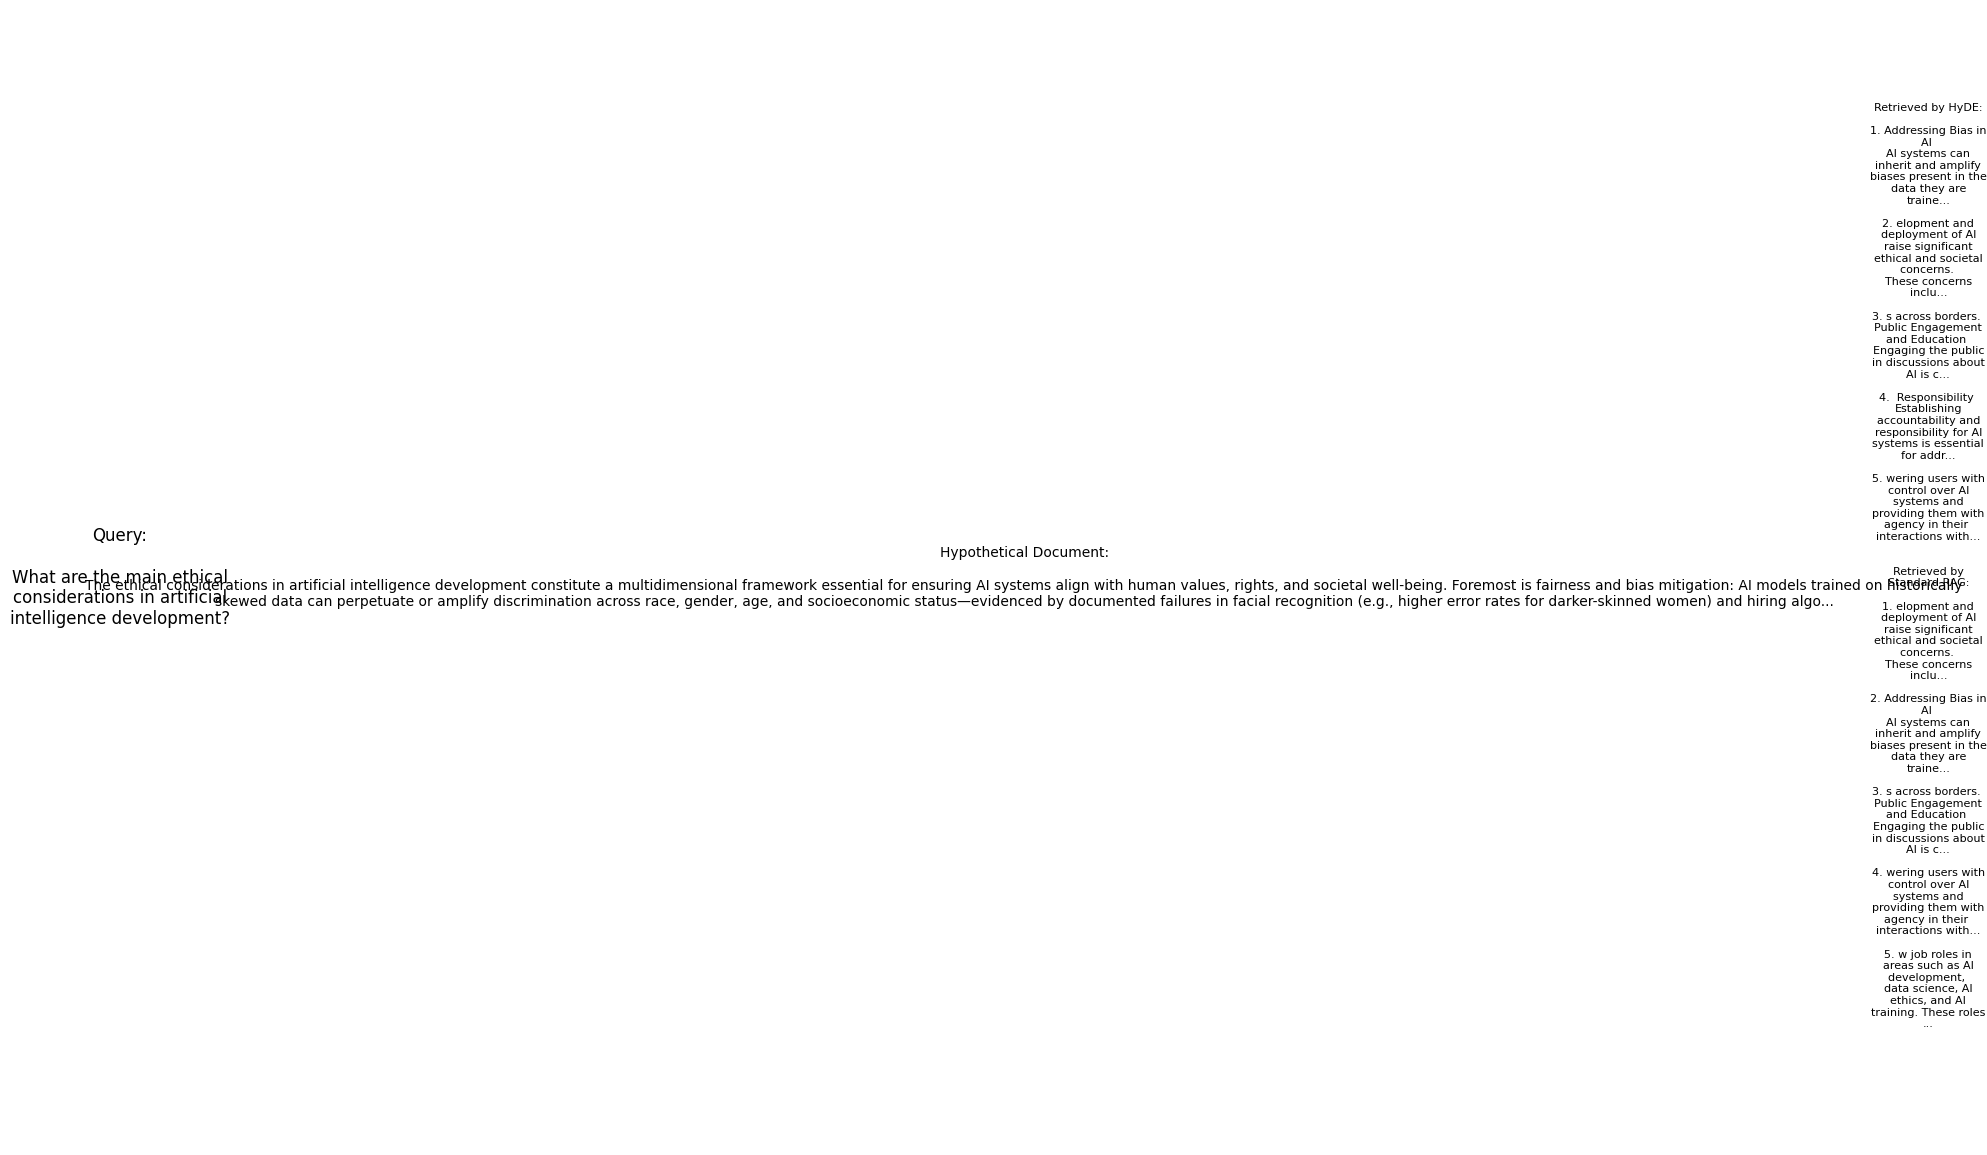

Extracting text from data/AI_Information.pdf...
Extracted 15 pages with content
Created 4 text chunks
Created 4 text chunks
Created 3 text chunks
Created 3 text chunks
Created 3 text chunks
Created 3 text chunks
Created 3 text chunks
Created 3 text chunks
Created 3 text chunks
Created 3 text chunks
Created 3 text chunks
Created 3 text chunks
Created 3 text chunks
Created 4 text chunks
Created 3 text chunks
Creating embeddings for chunks...
Vector store created with 48 chunks


===== Evaluating Query 1/1 =====
Query: How does neural network architecture impact AI performance?

=== Processing query with HyDE: How does neural network architecture impact AI performance? ===

Generating hypothetical document...
Generated hypothetical document of 1760 characters
Creating embedding for hypothetical document...
Retrieving 5 most similar chunks...
Generating final response...

=== Processing query with Standard RAG: How does neural network architecture impact AI performance? ===

Creating embed

In [17]:
# AI信息文档的路径
pdf_path = "data/AI_Information.pdf"

# 处理文档并创建向量存储
# 这会加载文档、提取文本、分块并生成嵌入
vector_store = process_document(pdf_path)

# 示例1：针对单一AI相关查询进行直接比较
query = "What are the main ethical considerations in artificial intelligence development?"

# 运行HyDE RAG方法
# 这会生成一个回答查询的假设文档，对其进行嵌入，
# 然后使用该嵌入来检索相关的片段
hyde_result = hyde_rag(query, vector_store)
print("\n=== HyDE Response ===")
print(hyde_result["response"])

# 运行标准RAG方法进行对比
# 这会直接对查询进行嵌入，并使用它来检索相关的片段
standard_result = standard_rag(query, vector_store)
print("\n=== Standard RAG Response ===")
print(standard_result["response"])

# 可视化HyDE和标准RAG方法之间的差异
# 显示查询、假设文档和检索到的片段并排
visualize_results(query, hyde_result, standard_result)

# 示例2：使用多个AI相关查询运行全面评估
test_queries = [
    "How does neural network architecture impact AI performance?"
]

# 可选的参考答案以实现更好的评估
reference_answers = [
    "Neural network architecture significantly impacts AI performance through factors like depth (number of layers), width (neurons per layer), connectivity patterns, and activation functions. Different architectures like CNNs, RNNs, and Transformers are optimized for specific tasks such as image recognition, sequence processing, and natural language understanding respectively.",
]

# 运行综合评估，比较HyDE和标准RAG方法
evaluation_results = run_evaluation(
    pdf_path=pdf_path,
    test_queries=test_queries,
    reference_answers=reference_answers
)

# 打印跨查询哪种方法表现更好的总体分析
print("\n=== OVERALL ANALYSIS ===")
print(evaluation_results["overall_analysis"])

这是一份为你量身定制的、基于提纲的**假设文档嵌入 (HyDE)** 深度技术讲解文档。我将以导师带研究生的视角，从直觉到源码，把这个技术的骨肉完全拆解开来。

---

# 深入解析：假设文档嵌入 (HyDE) 在 RAG 中的原理与实践

在构建 RAG（检索增强生成）系统时，我们通常面临一个核心痛点：**用户提的问题往往非常简短且口语化，而知识库里的文档却是冗长且书面化的。** 这导致了两者在向量空间中的“语义鸿沟”。

基于你提供的笔记提纲，本文将深入剖析 **HyDE（Hypothetical Document Embeddings）** 这一创新检索技术，看看它是如何巧妙地弥合这一差距的。

---

## 1. 直观理解：从“盲人摸象”到“按图索骥”

为了通俗地理解 HyDE，我们可以做一个**“刑侦画像”的类比**。

假设你是一名警察，目击者只给你提供了一句极其简短的线索：“一个高个子，戴着黑框眼镜，嘴角有颗痣”（**用户的短查询**）。
如果你直接拿着这句话去茫茫人海（**知识库/文档集**）中进行文本匹配，效率和准确率会极低，因为路人的特征描述大多是“身高185cm，视力受损佩戴树脂镜片，面部特征包含黑色素沉积”这种书面语（**长文档**）。

**HyDE 的做法是什么？**
它先请一位“经验丰富的画像师（大语言模型 LLM）”，根据目击者这句简短的话，**凭空想象并画出一张完整的嫌疑人画像（假设的答案文档）**。
虽然这张画像里的很多细节（比如发型、衣服颜色）可能是画像师脑补的（**AI 幻觉**），但这张画像整体的“气质和面部结构”已经非常接近真实的嫌疑人了。
最后，你拿着这幅完整的画像去数据库里做“以图搜图（**文档到文档的向量检索**）”，这比直接用那一句话去搜，准确度要高得多。

---

## 2. 核心原理：为什么这样设计？

### 2.1 传统的非对称检索困境 (Asymmetric Retrieval)
在传统 RAG 中，检索过程是**非对称**的：短 Query $\rightarrow$ 长 Document。
嵌入模型（Embedding Model）在训练时，通常倾向于将长度相似、结构相似的文本聚类在一起。口语化的提问（如：“怎么解决 Python 内存泄漏？”）和官方文档（如：“Python 垃圾回收机制与内存管理深度解析”）在字面和语法结构上差异巨大，导致它们的向量在空间中距离较远。

### 2.2 HyDE 的范式转换：化“非对称”为“对称”
HyDE 的核心思想是**“用生成代替搜索”**。
既然短查询和长文档不好匹配，我们就利用 LLM 将短查询**膨胀（Expand）**成一篇长文档。
通过这种方式，HyDE 将原本的 `Query-to-Document` 检索，巧妙地转换成了 `Document-to-Document` 的检索问题。

**核心步骤拆解：**
1. **生成（Generation）**：让 LLM 回答用户的 query。重点是：**我们不在乎 LLM 此时生成的内容在事实上是否绝对正确（哪怕它产生了严重的幻觉）**。我们只在乎 LLM 生成的文本中**包含了丰富的目标领域相关词汇、术语和上下文模式**。
2. **嵌入（Embedding）**：将这个“假设文档”丢给 Embedding 模型，提取其稠密向量。这个向量捕获了假设文档的核心语义。
3. **检索（Retrieval）**：在向量数据库中，查找与该假设文档向量最接近的真实文档。那些带有相同术语和语境的真实文档，此时就会被成功召回。

---

## 3. 数学与机制解释

在 HyDE 的原始论文中，其机制可以被描述为一个无监督的、基于指令的生成过程。我们用简单的数学符号来定义：

设用户的原始查询为 $q$。
给定一个指令微调过的大型语言模型 $\text{LLM}$，以及一个无监督的对比学习编码器 $\text{Encoder}$（例如 Contriever 或 text-embedding-ada-002）。

1. **假设文档生成**：
   $$h = \text{LLM}(q, \text{Prompt})$$
   *变量解释*：$Prompt$ 是引导词（如“请写一段文章回答以下问题...”），$h$ 就是生成的假设文档（Hypothetical Document）。

2. **文档向量化**：
   $$v_h = \text{Encoder}(h)$$
   *变量解释*：$v_h$ 是假设文档在潜空间（Latent Space）中的向量表示。此时 $v_h$ 已经脱离了简短查询的分布，进入了长文档的分布空间。

3. **相似度匹配**：
   $$d_{target} = \arg\max_{d \in D} \text{CosineSimilarity}(v_h, \text{Encoder}(d))$$
   *变量解释*：$D$ 是我们知识库中所有真实文档的集合。我们在库中找到与假设向量 $v_h$ 夹角余弦值最大的真实文档 $d$ 作为最终召回结果。

---

## 4. 工程实现视角

作为工程师，我们要怎么把这个思想落地？下面是一段去除框架冗余、直击算法本质的 Python 伪代码实现。

```python
import openai
import numpy as np
from typing import List

class HyDERetriever:
    def __init__(self, vector_db, llm_client, embed_client):
        self.db = vector_db           # 你的向量数据库实例 (e.g., Milvus, FAISS)
        self.llm = llm_client         # LLM 客户端
        self.embedder = embed_client  # Embedding 客户端

    def _generate_hypothetical_document(self, query: str) -> str:
        """
        步骤 1: 零样本生成假设文档。
        Prompt 的设计非常关键，必须引导模型生成“看起来像标准答案”的文本。
        """
        prompt = f"""
        你是一个专业领域的知识专家。请针对下面的问题，写一篇详细的、包含专业术语的解答文档。
        即便你不知道确切的答案，也请尽可能详细地描述相关的概念和可能的情况。
        
        问题: {query}
        解答:
        """
        response = self.llm.chat.completions.create(
            model="qwen-plus", # 这里不需要用最贵最慢的模型，只要语言能力好即可
            messages=[{"role": "user", "content": prompt}]
        )
        return response.choices[0].message.content

    def retrieve(self, query: str, top_k: int = 5) -> List[str]:
        # 1. 扩写：生成假设文档
        hypo_doc = self._generate_hypothetical_document(query)
        print(f"[Debug] 生成的假设文档截取: {hypo_doc[:100]}...")
        
        # 2. 嵌入：计算假设文档的向量，而不是计算原始 query 的向量
        query_vector = self.embedder.get_embedding(hypo_doc)
        
        # 3. 检索：用假设文档的向量去知识库里捞取真实文档
        results = self.db.search(query_vector, top_k=top_k)
        
        return results
```

**工程洞察：**
你看，实现 HyDE 其实非常简单，本质上就是**在计算 Embedding 之前，插入了一个 LLM 生成的拦截器**。代码中没有修改底层向量库的任何逻辑。

---

## 5. 实际应用场景：什么时候该用？

HyDE 并不是银弹，它在以下特定场景中表现最耀眼：

1. **跨领域/冷启动（Zero-shot Domain Adaptation）**：
   * *场景*：你正在构建一个极度专业的法律文书检索系统，但你手上**没有**人工标注的 `(Query, 法律条文)` 对去微调 Embedding 模型。普通的 Embedding 模型由于没见过法律术语，检索极差。
   * *为什么适合*：LLM 内部见过无数法律术语（哪怕它不能准确背诵）。通过生成一份“假文书”，HyDE 直接激活了蕴含在 LLM 权重中的世界知识，代替了原本需要耗费巨资进行的 Embedding 模型领域微调。

2. **极度简短或抽象的提问**：
   * *场景*：用户搜索“系统报 Error 503”，知识库里的文档标题通常是“服务器过载及 Nginx 超时配置排查指南”。
   * *为什么适合*：直接搜“Error 503”匹配度极低。HyDE 生成的假文档中会自动包含“Nginx, 超时, 负载均衡, HTTP 状态码”等关键词，从而精准命中真实文档。

---

## 6. 额外增强：对比与复杂度分析

### 6.1 对比：HyDE vs. 传统 Query Expansion
* **传统 Query Expansion (如基于同义词或 BM25 变体)**：通常只是增加几个同义词（比如搜“苹果”，补充“手机, iPhone”）。它依然是基于字面映射的。
* **HyDE**：不只是加词，而是构建了**完整的语境和上下文结构**。 Embedding 模型（基于 Transformer 的架构）极度依赖上下文注意力（Attention）机制。连贯的句子能让 Embedding 提取出的向量具有更深层的语义聚集效应，这是散乱的同义词堆砌做不到的。

### 6.2 复杂度与性能 trade-off
* **时间复杂度**：标准 RAG 是 $O(1)$ 的 Embedding 推理；HyDE 是 $O(N)$ 的 LLM 自回归解码（$N$ 为假设文档长度）+ $O(1)$ 的 Embedding 推理。**这是 HyDE 最大的短板**，它显著增加了检索的绝对延迟（通常增加 1-2 秒）。
* **工程优化技巧**：在生产环境中，强烈建议为 HyDE 的生成步骤使用**小参数量、高并发的模型**（如 Llama-3-8B 或 GPT-3.5 甚至 GPT-4o-mini），并严格限制 `max_tokens`（例如限制在 200字以内）。因为对于提取向量而言，只要核心词汇和上下文出来了就足够了，不需要长篇大论。

---

## 7. 常见问题 / 易错点（避坑指南）

1. **安全词陷阱（"I don't know" 灾难）**
   * *踩坑*：如果用户的查询过于偏门，LLM 可能会出于安全机制回答：“抱歉，我不知道这个问题的答案。” 此时你的程序会将“抱歉，我不知道...”去计算 Embedding，这会完全毁掉这次检索！
   * *对策*：必须在 System Prompt 中加入强指令，例如：*“禁止回答你不知道。即便信息不足，你也必须基于常识虚构一篇相关的探讨性文章，使用该领域的术语。”*

2. **过度发散导致语义漂移（Semantic Drift）**
   * *踩坑*：如果 Prompt 没写好，LLM 生成的假设文档可能会偏离用户最初的问题核心。
   * *对策*：在实际工业界，有时会将**原始 Query 的向量**和**HyDE 假设文档的向量**做一个加权融合（例如 `0.3 * Query_Vector + 0.7 * HyDE_Vector`），然后再去检索。这样既保留了原始查询的精确硬匹配特征，又拥有了 HyDE 的丰富语义。

总结来说，HyDE 是 RAG 工程中极其优雅的一步棋：它承认了 Embedding 模型的局限性，转而向具有浩瀚知识压缩能力的 LLM 借力，用“虚构的答案”找到了“真实的知识”。

这个问题问得非常直击本质！在 RAG 的优化链路里，“查询改写”（Query Rewrite）和“HyDE”确实很容易被混淆，因为它们都属于\*\*“检索前（Pre-retrieval）优化”\*\*，都要用到 LLM，且目的都是为了“搜得更准”。

但它们在**底层逻辑、操作空间和解决的痛点上，有着截然不同的定位**。作为你的“导师”，我带你从三个维度把这两个概念彻底拆解开。

-----

### 1\. 直观类比：一个是“润色提问”，一个是“凭空造答案”

假设你是一个去图书馆找书的学生，你对图书管理员（检索系统）说：**“有没有讲那个被咬了一口的苹果的？”**

  * **查询改写（Query Rewrite）的做法：**
    管理员心想：这表述太口语化了，直接搜肯定搜不到。于是管理员帮你**把“提问”翻译成了更好的“提问”**：
    $\rightarrow$ *“用户想找的是科技公司还是水果？结合上下文，应该是科技公司。我把查询改成：『苹果公司 (Apple Inc.) 的历史与乔布斯传记』”*
    **本质：** 你的输入依然是一个**查询指令（Query）**，只是变得更清晰、关键词更丰富了。

  * **HyDE 的做法：**
    管理员不帮你改写问题，而是直接**自己当场写了一段“书本摘要”**：
    $\rightarrow$ *“这家公司由史蒂夫·乔布斯创立，总部位于库比蒂诺，推出了 iPhone、Mac 等革命性产品，其标志是一个被咬了一口的苹果……”*
    然后，管理员拿着这段摘要，去跟图书馆里所有书的背面简介进行比对（找相似度）。
    **本质：** 你的输入被转换成了一个**假设的答案文档（Document）**。

-----

### 2\. 向量空间的视角：空间漫游 vs. 跨维打击

如果你站在 Embedding 模型的\*\*高维向量空间（Latent Space）\*\*来看，这两者的区别最为明显：

  * **查询改写：在“问题空间（Query Space）”内微调位置**
    无论你怎么改写（纠正错别字、提取关键词、分解多步问题），生成的文本在语法结构上依然是“短句”或“搜索词”。在向量空间里，改写后的向量只是从原始向量旁边稍微挪动了一下，**它依然处于“短查询”的聚类分布中**。

  * **HyDE：从“问题空间”跃迁到“文档空间（Document Space）”**
    我们在上一篇笔记提到过**非对称检索（Asymmetric Retrieval）**。问题（短）和答案（长）在向量空间里天然相隔很远。
    HyDE 的厉害之处在于，它通过 LLM 的生成能力，直接越过了中间的鸿沟，**生成了一篇长文档，直接空降到了“文档空间”里**。它把不对称的 `Query-to-Doc` 匹配，强行变成了对称的 `Doc-to-Doc` 匹配。

-----

### 3\. 工程视角：它们分别解决什么痛点？

这两种技术不是互斥的，而是互补的，因为它们对付的“病症”不同：

| 维度 | 查询改写 (Query Rewrite) | 假设文档嵌入 (HyDE) |
| :--- | :--- | :--- |
| **核心机制** | $Query \rightarrow Query'$ | $Query \rightarrow Fake\ Document$ |
| **解决的主要痛点** | **指代不明、意图模糊、复杂多步**<br>例如：把“它怎么用？”改写为“Python 垃圾回收机制怎么用？” | **词汇鸿沟、非对称语义**<br>例如：把“电脑好卡”映射到“CPU 降频与内存条频率排查” |
| **输出长度** | 短（几个词到一两句话） | 长（通常是一个段落或一篇文章） |
| **延迟 (Latency)** | 较低（LLM 生成短文本很快） | 较高（LLM 需要自回归生成长文本） |
| **幻觉风险** | 低（只是重组提取用户意图） | 高（LLM 可能会虚构出不存在的具体数值或概念） |

-----

### 💡 总结与架构建议

在真正的工业级 RAG 架构中，**查询改写和 HyDE 往往是串联或并联使用的**。

一个成熟的检索 Pipeline 可能是这样的：

1.  **用户输入**：“这俩有啥区别？”
2.  **模块 A：查询改写（指代消解）** $\rightarrow$ LLM 结合历史对话，改写为：“查询改写和 HyDE 在 RAG 系统中有什么区别？”
3.  *(分流判断)*：系统发现这是一个需要深度技术解答的问题，触发 HyDE。
4.  **模块 B：HyDE** $\rightarrow$ LLM 基于改写后的清晰问题，生成一篇 200 字的技术科普短文（假设文档）。
5.  **检索库** $\rightarrow$ 用这篇科普短文的 Embedding 向量去匹配知识库。

**一句话总结：**
**查询改写**是教大模型“如何像一个专业的搜索专家那样提问”；
**HyDE**是教大模型“如何像一个懂行的专家那样先给个草稿，再按图索骥”。